In [1]:
import os
import sys
import math
import random
import hashlib
import zlib
from typing import Tuple
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter
from scipy import stats
import soundfile as sf  # pip install soundfile
from io import BytesIO
from tensorflow.keras.datasets import mnist

In [2]:
# utilites

def bytes_to_bits(b: bytes) -> str:
    return ''.join(f'{x:08b}' for x in b)

def bits_to_bytes(bitstr: str) -> bytes:
    # pad to multiple of 8
    pad = (-len(bitstr)) % 8
    if pad:
        bitstr += '0' * pad
    return bytes(int(bitstr[i:i+8], 2) for i in range(0, len(bitstr), 8))

def sha256_expand(seed_bytes: bytes, out_len: int) -> bytes:
    # Simple counter-mode using SHA-256: expand seed_bytes into out_len bytes
    out = bytearray()
    counter = 0
    while len(out) < out_len:
        h = hashlib.sha256(seed_bytes + counter.to_bytes(8, 'big')).digest()
        out.extend(h)
        counter += 1
    return bytes(out[:out_len])

In [3]:
# TRNG (audio)

def wav_to_lsb_bitstream(wav_path: str, lsb_count=1):
    data, samplerate = sf.read(wav_path, dtype='int16')
    # If stereo, flatten channels
    if data.ndim == 2:
        data_bytes = data.flatten().tobytes()
    else:
        data_bytes = data.tobytes()
    # extract lsb from each byte
    lsb_stream = ''.join((f'{byte:08b}'[-1]) for byte in data_bytes)
    return bits_to_bytes(lsb_stream)

In [4]:
# PRNG (xorshift)

class XorShift64Star:
    def __init__(self, seed=None):
        if seed is None:
            seed = random.getrandbits(64)
        # ensure non-zero seed
        self.state = seed & ((1<<64)-1) or 0xdeadbeefcafebabe
    def next_uint64(self):
        x = self.state
        x ^= (x >> 12) & ((1<<64)-1)
        x ^= (x << 25) & ((1<<64)-1)
        x ^= (x >> 27) & ((1<<64)-1)
        self.state = x
        return (x * 2685821657736338717) & ((1<<64)-1)
    def next_bytes(self, n):
        out = bytearray()
        while len(out) < n:
            v = self.next_uint64()
            out.extend(v.to_bytes(8,'big'))
        return bytes(out[:n])

In [5]:
# Encryption

def keystream_from_trng(bitstream_bytes: bytes, length_bytes: int) -> bytes:
    return sha256_expand(bitstream_bytes, length_bytes)

def keystream_from_prng(seed_bytes: bytes, length_bytes: int, use_seed_from_wav=False):
    if use_seed_from_wav and seed_bytes:
        seed = int.from_bytes(hashlib.sha256(seed_bytes).digest()[:8], 'big')
    else:
        seed = random.getrandbits(64) # from OS
    prng = XorShift64Star(seed=seed)
    return prng.next_bytes(length_bytes)

def xor_encrypt_image_bytes(img_bytes: bytes, keystream: bytes) -> bytes:
    if len(keystream) < len(img_bytes):
        raise ValueError("Keystream shorter than image bytes")
    return bytes(a ^ b for a,b in zip(img_bytes, keystream))

def flatten_image_to_bytes(image: np.ndarray):
    # image is 2D (grayscale) or 3D (color)
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)
    return image.tobytes()

def bytes_to_image(b: bytes, shape, mode='L'):
    arr = np.frombuffer(b, dtype=np.uint8)
    arr = arr.reshape(shape)
    return arr

In [6]:
# Metrics

def npcr(img_a: np.ndarray, img_b: np.ndarray) -> float:
    # Percent of pixel positions that change
    assert img_a.shape == img_b.shape
    total = img_a.size
    diff = np.count_nonzero(img_a != img_b)
    return (diff / total) * 100.0

def uaci(img_a: np.ndarray, img_b: np.ndarray) -> float:
    assert img_a.shape == img_b.shape
    img_a = img_a.astype(np.int32)
    img_b = img_b.astype(np.int32)
    diff = np.abs(img_a - img_b)
    return (np.sum(diff) / (img_a.size * 255.0)) * 100.0

def shannon_entropy(byte_data: bytes) -> float:
    if len(byte_data) == 0:
        return 0.0
    ctr = Counter(byte_data)
    total = len(byte_data)
    ent = -sum((v/total) * math.log2(v/total) for v in ctr.values())
    return ent

def histogram_chi_square(img: np.ndarray):
    # Compare observed histogram to expected uniform using chi-square statistic
    flat = img.flatten()
    counts = np.bincount(flat, minlength=256)
    expected = np.full(256, flat.size / 256.0)
    chi2 = ((counts - expected)**2 / expected).sum()
    dof = 255
    p = 1 - stats.chi2.cdf(chi2, dof)
    return chi2, p

def adjacent_pixel_correlation(img: np.ndarray, sample_size=5000):
    h, w = img.shape[:2]
    # sample random positions avoiding border for pairs
    rng = np.random.default_rng()
    xs = rng.integers(0, h, size=sample_size)
    ys = rng.integers(0, w-1, size=sample_size)  # horizontal pair
    vals_x = img[xs, ys].astype(np.float64)
    vals_y = img[xs, ys+1].astype(np.float64)
    r, _ = stats.pearsonr(vals_x, vals_y)
    return r

In [7]:
# Attack Simulations

def flip_random_cipher_bits(cipher_bytes: bytes, bit_error_rate: float):
    b = bytearray(cipher_bytes)
    nbits = len(b) * 8
    nflip = int(nbits * bit_error_rate)
    if nflip == 0:
        return bytes(b)
    flip_positions = np.random.choice(nbits, size=nflip, replace=False)
    for pos in flip_positions:
        byte_idx = pos // 8
        bit_idx = pos % 8
        b[byte_idx] ^= (1 << (7-bit_idx))
    return bytes(b)

def single_bit_flip(cipher_bytes: bytes, pos:int=0):
    b = bytearray(cipher_bytes)
    byte_idx = pos // 8
    bit_idx = pos % 8
    b[byte_idx] ^= (1 << (7-bit_idx))
    return bytes(b)

# PSNR / MSE
def mse(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return np.mean((a - b) ** 2)

def psnr(a, b):
    m = mse(a,b)
    if m == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * math.log10(PIXEL_MAX / math.sqrt(m))

In [8]:
# Grass texture

def generate_grass_texture(size: Tuple[int, int], seed: int = None) -> Image.Image:
    if seed is not None: rng = np.random.default_rng(seed)
    else: rng = np.random.default_rng()

    w, h = size
    base = np.zeros((h, w, 3), dtype=np.uint8)

    for y in range(h):
        g = int(100 + 80 * (y / h))  # gradient green
        base[y, :, 1] = g
        base[y, :, 0] = int(g * 0.3)

    img = Image.fromarray(base, mode='RGB')
    draw = ImageDraw.Draw(img)
    num_blades = (w * h) // 40

    for _ in range(num_blades):
        x = rng.integers(0, w)
        y = rng.integers(0, h)
        length = rng.integers(max(1, h // 40), max(2, h // 8))
        x2 = x + rng.integers(-2, 3)
        y2 = min(h - 1, y + length)
        green_shade = int(120 + rng.integers(0, 120))
        color = (int(green_shade * 0.25), green_shade, int(green_shade * 0.15))
        draw.line([(x, y), (x2, y2)], fill=color, width=1)

    return img

In [9]:
# Image selection

def select_image():
    print("Select image input option:")
    print("1. Random image from MNIST dataset")
    print("2. Upload your own image (keeps original resolution)")
    choice = int(input("Enter 1 or 2: ").strip())
    if choice == 1:
        (x_train, _), (_, _) = mnist.load_data()
        idx = np.random.randint(0, len(x_train))
        image = x_train[idx]
        print(f"Selected MNIST index: {idx}, shape: {image.shape}")
        return image, ('L', image.shape)
    elif choice == 2:
        try:
            from tkinter import Tk, filedialog
            Tk().withdraw()
            file_path = filedialog.askopenfilename(
                title="Select image to encrypt",
                filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.tiff *.gif")]
            )
            if not file_path:
                raise ValueError("No file selected.")
            pil = Image.open(file_path).convert('L')  # grayscale
            arr = np.array(pil).astype(np.uint8)
            print(f"Uploaded image: {file_path}, shape: {arr.shape}")
            return arr, ('L', arr.shape)
        except Exception as e:
            raise RuntimeError(f"File dialog failed or environment unsupported: {e}")
    else:
        raise ValueError("Invalid input")

In [10]:
# Decryption

def decrypt_trng_bytes(encrypted_image: np.ndarray, keystream: bytes, shape: tuple) -> np.ndarray:
    enc_bytes = encrypted_image.flatten().astype(np.uint8)
    ks = np.frombuffer(keystream[:len(enc_bytes)], dtype=np.uint8)
    dec_bytes = np.bitwise_xor(enc_bytes, ks)
    decrypted_image = dec_bytes.reshape(shape)
    return decrypted_image

In [15]:
# main pipeline

def main_pipeline(wav_path=None, prng_seed_from_wav=False, attack_rates=[0.0, 1e-4, 1e-3, 1e-2], grass_seed=123456789, apply_grass_mask=True):
    image, meta = select_image()
    is_color = (image.ndim == 3)
    shape = image.shape
    print("Image shape:", shape)
    
    img_bytes = flatten_image_to_bytes(image)
    n_bytes = len(img_bytes)
    print(f"Image bytes length: {n_bytes}")
    
    if wav_path is None: # getting TRNG bitstream
        print("No wav path provided. TRNG path will be derived from a small random seed.")
        trng_bitbytes = hashlib.sha256(b"default").digest()
    else:
        trng_bitbytes = wav_to_lsb_bitstream(wav_path)
    print(f"TRNG bitstream bytes: {len(trng_bitbytes)}")

    # derive keystreams
    ks_trng = keystream_from_trng(trng_bitbytes, n_bytes)
    ks_prng = keystream_from_prng(trng_bitbytes if prng_seed_from_wav else None, n_bytes, use_seed_from_wav=prng_seed_from_wav)

#    if apply_grass_mask: # applying grass texture mask into keystream
 #       width, height = shape[1], shape[0]
  #      texture_arr = generate_grass_texture_array((width, height), seed=grass_seed, as_gray=True)
   #     ks_trng_used = mix_texture_into_keystream(ks_trng, texture_arr)
    #else:        ks_trng_used = ks_trng
    
    # encrypt both ways
    cipher_trng = xor_encrypt_image_bytes(img_bytes, ks_trng)
    cipher_prng = xor_encrypt_image_bytes(img_bytes, ks_prng)

    # Reconstruct encrypted images
    enc_trng_img = bytes_to_image(cipher_trng, shape)
    enc_prng_img = bytes_to_image(cipher_prng, shape)

    grass = generate_grass_texture((shape[1], shape[0]))
    grass = np.array(grass.resize((shape[1], shape[0])))
    if enc_trng_img.ndim == 2:  # grayscale -> make RGB for overlay
        enc_trng_rgb = np.stack([enc_trng_img]*3, axis=-1)
    else:
        enc_trng_rgb = enc_trng_img
    blended_trng = np.clip(0.7 * enc_trng_rgb + 0.3 * grass, 0, 255).astype(np.uint8)

    fig, axs = plt.subplots(1,4, figsize=(16,4))
    axs[0].imshow(image, cmap='gray')
    axs[0].set_title("Original")
    axs[0].axis('off')

    axs[1].imshow(enc_trng_img, cmap='gray')
    axs[1].set_title("Cipher (TRNG)")
    axs[1].axis('off')

    axs[2].imshow(enc_prng_img, cmap='gray')
    axs[2].set_title("Cipher (PRNG)")
    axs[2].axis('off')

    axs[3].imshow(blended_trng)
    axs[3].set_title("TRNG + Grass Mask")
    axs[3].axis('off')
    plt.show()

    # metrics
    print("\n--- Comparison metrics between TRNG and PRNG ciphertext images ---")
    npcr_val = npcr(enc_trng_img, enc_prng_img)
    uaci_val = uaci(enc_trng_img, enc_prng_img)
    print(f"\nNPCR (TRNG vs PRNG): {npcr_val:.4f} %")
    print(f"UACI (TRNG vs PRNG): {uaci_val:.4f} %")

    ent_trng = shannon_entropy(cipher_trng)
    ent_prng = shannon_entropy(cipher_prng)
    print(f"\nCiphertext entropy (TRNG): {ent_trng:.4f} bits/byte")
    print(f"Ciphertext entropy (PRNG): {ent_prng:.4f} bits/byte")

    chi_trng, p_trng = histogram_chi_square(enc_trng_img)
    chi_prng, p_prng = histogram_chi_square(enc_prng_img)
    print(f"\nHistogram chi2 TRNG: {chi_trng:.2f}, p-value={p_trng:.4g}")
    print(f"Histogram chi2 PRNG:  {chi_prng:.2f}, p-value={p_prng:.4g}")

    corr_trng = adjacent_pixel_correlation(enc_trng_img)
    corr_prng = adjacent_pixel_correlation(enc_prng_img)
    print(f"\nAdj. pixel correlation (TRNG ciphertext): {corr_trng:.6f}")
    print(f"Adj. pixel correlation (PRNG ciphertext):  {corr_prng:.6f}")

    # simulating attacks on ciphertext to attempt decryption
    print("\n--- Simulated channel attacks on TRNG ciphertext (random bit flips) ---")
    for ber in attack_rates:
        if ber <= 0.0:
            print(f"BER={ber}: skipping flips (no attack)")
            continue
        modified_cipher = flip_random_cipher_bits(cipher_trng, ber)
        try:
            dec_bytes = xor_encrypt_image_bytes(modified_cipher, ks_trng)
            dec_img = bytes_to_image(dec_bytes, shape)
            m = mse(image, dec_img)
            p = psnr(image, dec_img)
            print(f"BER={ber:.6f} -> MSE={m:.3f}, PSNR={p:.3f} dB")
        except Exception as e:
            print(f"BER={ber} -> Decryption failed: {e}")

    # Single-bit flip test
    print("\nSingle-bit flip test (first bit):")
    mod1 = single_bit_flip(cipher_trng, pos=0)
    dec1 = xor_encrypt_image_bytes(mod1, ks_trng)
    dec1_img = bytes_to_image(dec1, shape)
    print(f"Single-bit flip -> MSE={mse(image, dec1_img):.3f}, PSNR={psnr(image, dec1_img):.3f} dB")

    # summary
    print("\n--- Summary (TRNG vs PRNG) ---")
    print(f"* NPCR (TRNG vs PRNG): {npcr_val:.4f}% (higher means ciphertexts differ more)")
    print(f"* UACI (TRNG vs PRNG): {uaci_val:.4f}% (higher means greater intensity changes)")
    print(f"* Entropy TRNG: {ent_trng:.4f} bits/byte, PRNG: {ent_prng:.4f} bits/byte (closer to 8 is better)")
    print(f"* Histogram p-values (chi-square): TRNG p={p_trng:.4g}, PRNG p={p_prng:.4g} (higher p ~ closer to uniform)")
    print(f"* Adjacent pixel correlation: TRNG {corr_trng:.6f}, PRNG {corr_prng:.6f} (closer to 0 is better)")

    print("\nDisplaying Decrypted Image")
    decrypted_trng = decrypt_trng_bytes(enc_trng_img, ks_trng, shape)
    plt.imshow(decrypted_trng, cmap='gray')
    plt.title("Decrypted (TRNG)")
    plt.axis('off')
    plt.show()

    # crude decision rule
    score = 0
    if ent_trng > ent_prng: score += 1
    if abs(corr_trng) < abs(corr_prng): score += 1
    if p_trng > p_prng: score += 1
    if npcr_val > 50: score += 0.5  # arbitrary
    print("\nVerdict (simple heuristic):")
    if score >= 2:
        print("TRNG-based encryption performs better overall on these quick metrics.")
    else:
        print("PRNG-based encryption performs similar or better based on these quick metrics.")
    return {
        'metrics': {
            'npcr': npcr_val,
            'uaci': uaci_val,
            'entropy_trng': ent_trng,
            'entropy_prng': ent_prng,
            'chi_trng': (chi_trng, p_trng),
            'chi_prng': (chi_prng, p_prng),
            'corr_trng': corr_trng,
            'corr_prng': corr_prng
        }
    }

Select image input option:
1. Random image from MNIST dataset
2. Upload your own image (keeps original resolution)


Enter 1 or 2:  1


Selected MNIST index: 12815, shape: (28, 28)
Image shape: (28, 28)
Image bytes length: 784
TRNG bitstream bytes: 198450


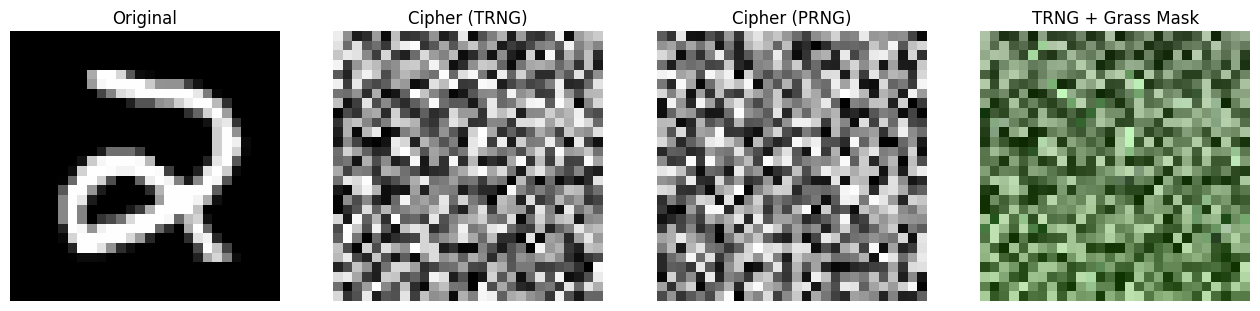


--- Comparison metrics between TRNG and PRNG ciphertext images ---

NPCR (TRNG vs PRNG): 99.6173 %
UACI (TRNG vs PRNG): 32.4675 %

Ciphertext entropy (TRNG): 7.7341 bits/byte
Ciphertext entropy (PRNG): 7.7670 bits/byte

Histogram chi2 TRNG: 260.90, p-value=0.3864
Histogram chi2 PRNG:  234.78, p-value=0.8134

Adj. pixel correlation (TRNG ciphertext): 0.011579
Adj. pixel correlation (PRNG ciphertext):  -0.029988

--- Simulated channel attacks on TRNG ciphertext (random bit flips) ---
BER=0.0: skipping flips (no attack)
BER=0.000100 -> MSE=0.000, PSNR=inf dB
BER=0.001000 -> MSE=23.046, PSNR=34.505 dB
BER=0.010000 -> MSE=199.297, PSNR=25.136 dB

Single-bit flip test (first bit):
Single-bit flip -> MSE=20.898, PSNR=34.930 dB

--- Summary (TRNG vs PRNG) ---
* NPCR (TRNG vs PRNG): 99.6173% (higher means ciphertexts differ more)
* UACI (TRNG vs PRNG): 32.4675% (higher means greater intensity changes)
* Entropy TRNG: 7.7341 bits/byte, PRNG: 7.7670 bits/byte (closer to 8 is better)
* Histogram 

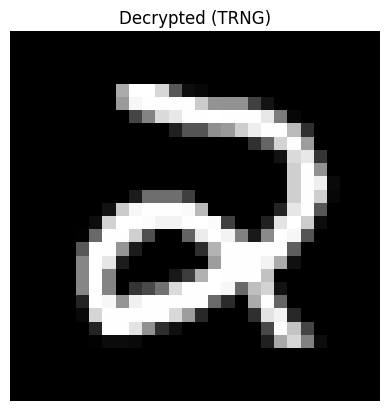


Verdict (simple heuristic):
PRNG-based encryption performs similar or better based on these quick metrics.


{'metrics': {'npcr': 99.61734693877551,
  'uaci': np.float64(32.467486994797916),
  'entropy_trng': 7.734090708115998,
  'entropy_prng': 7.7670106141561615,
  'chi_trng': (np.float64(260.8979591836735), np.float64(0.3864250587056288)),
  'chi_prng': (np.float64(234.77551020408163), np.float64(0.8134455858734865)),
  'corr_trng': np.float64(0.011579046777107839),
  'corr_prng': np.float64(-0.02998764057632116)}}

In [16]:
main_pipeline(wav_path = 'Tore_up_wav.wav')